In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load the raw dataset
df = pd.read_csv("../data/raw/customs_kaggle_raw.csv")

# basic shape
print(df.shape)
df.head()

(14873, 22)


,Declaration_ID,Date,Port_of_Entry,Importer_BIN,Agent_ID,Declared_HS_Code,Declared_Description,Country_of_Origin,Country_of_Departure,Declared_Weight_KG,...,Statistical_Unit,Exchange_Rate,CD_Rate,SD_Rate,VAT_Rate,AIT_Rate,RD_Rate,TTI_Rate,Risk_Channel,Fraud
0,C-2021-1009079,2022-01-11,Benapole Land Port,BIN-296659062,CHA-3215,73083000,"Doors, Window-Frames And Thresholds For Doors ...",US,US,19.0,...,KGM,83.00,25.0,0.0,15.0,5.0,3.0,58.6,Green,0
1,C-2021-1007129,2022-01-24,Dhaka ICD Kamalapur,BIN-880247781,CHA-4338,71069200,Semi-Manufactured Silver (Incl. Silver Plated ...,US,US,0.2,...,KGM,86.33,6.0,0.0,15.0,0.0,0.0,27.2,Green,0
2,C-2020-1006836,2022-05-01,Chittagong Sea Port,BIN-635293704,CHA-7300,87088000,Suspension shock absorbers,CN,CN,2565.0,...,KGM,85.52,10.0,0.0,15.0,5.0,0.0,37.0,Green,0
3,C-2020-1007372,2023-03-12,Chittagong Sea Port,BIN-482945712,CHA-9362,95067000,Ice Skates And Roller Skates,CN,BG,570.0,...,NPR,85.99,10.0,0.0,15.0,5.0,0.0,37.0,Green,0
4,C-2021-1011151,2023-09-23,Dhaka ICD Kamalapur,BIN-411525351,CHA-5892,90015000,Spectacle Lenses (Excl. Of Glass),TH,TH,10.2,...,NMB,83.48,5.0,0.0,15.0,5.0,0.0,31.0,Green,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14873 entries, 0 to 14872
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Declaration_ID        14873 non-null  str    
 1   Date                  14873 non-null  str    
 2   Port_of_Entry         14873 non-null  str    
 3   Importer_BIN          14873 non-null  str    
 4   Agent_ID              14460 non-null  str    
 5   Declared_HS_Code      14873 non-null  int64  
 6   Declared_Description  14638 non-null  str    
 7   Country_of_Origin     14562 non-null  str    
 8   Country_of_Departure  14655 non-null  str    
 9   Declared_Weight_KG    14873 non-null  float64
 10  Declared_Value_BDT    14873 non-null  float64
 11  Scanned_Weight_KG     13346 non-null  float64
 12  Statistical_Unit      14706 non-null  str    
 13  Exchange_Rate         14873 non-null  float64
 14  CD_Rate               14873 non-null  float64
 15  SD_Rate               14594 no

In [3]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

Scanned_Weight_KG       1527
Agent_ID                 413
Country_of_Origin        311
SD_Rate                  279
Declared_Description     235
Country_of_Departure     218
Statistical_Unit         167
dtype: int64


Fraud
0    12590
1     2283
Name: count, dtype: int64
fraud rate: 0.15349963020238014


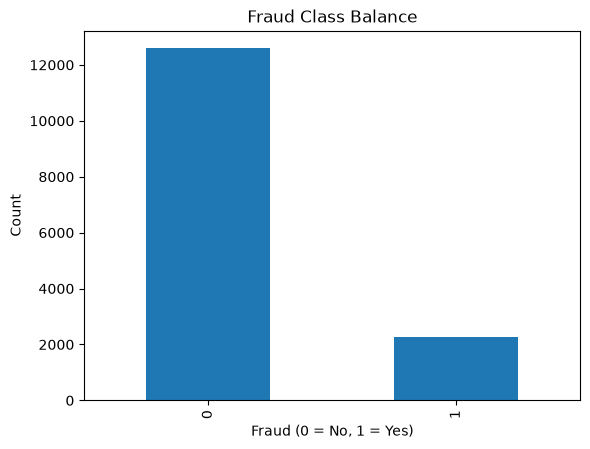

In [4]:
# checking fraud vs non-fraud balance
fraud_counts = df["Fraud"].value_counts()
fraud_rate = df["Fraud"].mean()

print(fraud_counts)
print("fraud rate:", fraud_rate)

fraud_counts.plot(kind="bar")
plt.title("Fraud Class Balance")
plt.xlabel("Fraud (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

Fraud               0        1
Risk_Channel                  
Green         0.93884  0.06116
Red           0.35769  0.64231
Yellow        0.83306  0.16694


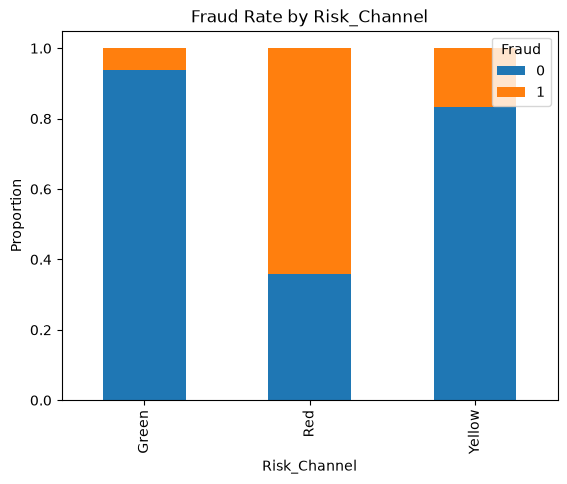

In [5]:
# checking if Risk_Channel already predicts fraud (leakage risk)
risk_fraud = pd.crosstab(df["Risk_Channel"], df["Fraud"], normalize="index")
print(risk_fraud)

risk_fraud.plot(kind="bar", stacked=True)
plt.title("Fraud Rate by Risk_Channel")
plt.ylabel("Proportion")
plt.show()

         count         mean          std       min   25%   50%   75%  \
Fraud                                                                  
0      11205.0    10.664274   627.374188 -12283.13 -0.94  0.00  1.27   
1       2141.0  1072.681331  9909.264677  -7635.98 -0.38  0.03  6.11   

             max  
Fraud             
0       18790.24  
1      190144.17  


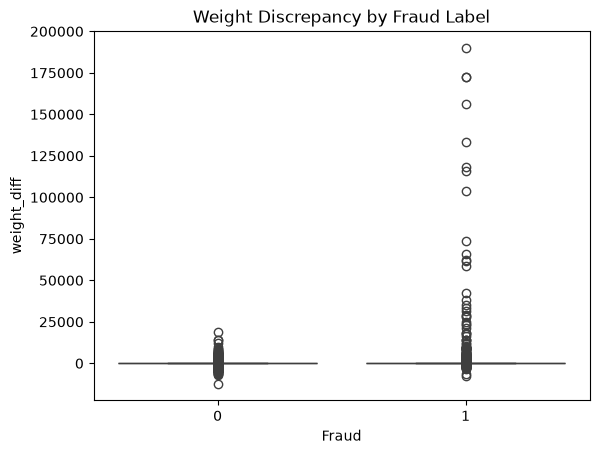

In [6]:
# declared vs scanned weight mismatch checking, a likely strong fraud signal
df["weight_diff"] = df["Scanned_Weight_KG"] - df["Declared_Weight_KG"]

print(df.groupby("Fraud")["weight_diff"].describe())

sns.boxplot(x="Fraud", y="weight_diff", data=df)
plt.title("Weight Discrepancy by Fraud Label")
plt.show()

         count          mean            std        min          25%  \
Fraud                                                                 
0      12590.0  56585.736051  172401.954845  29.854571  1686.641264   
1       2283.0  44279.335675  133140.995224  10.765278  2091.659514   

                50%           75%           max  
Fraud                                            
0       9768.360000  35282.004551  1.981925e+06  
1      14003.914894  37884.447895  1.707228e+06  


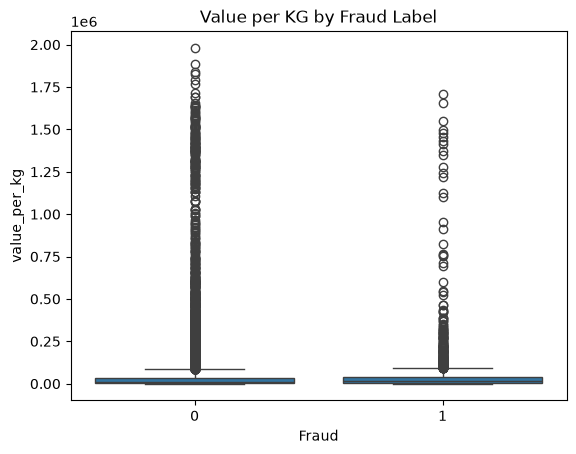

In [7]:
# declared value per kg, unusually low/high values can signal under/over-invoicing
df["value_per_kg"] = df["Declared_Value_BDT"] / df["Declared_Weight_KG"]

print(df.groupby("Fraud")["value_per_kg"].describe())

sns.boxplot(x="Fraud", y="value_per_kg", data=df)
plt.title("Value per KG by Fraud Label")
plt.show()

In [8]:
from scipy import stats

# t-test: is weight_diff significantly different between fraud and non-fraud?
fraud_wd = df[df["Fraud"] == 1]["weight_diff"].dropna()
clean_wd = df[df["Fraud"] == 0]["weight_diff"].dropna()
t_stat, p_val = stats.ttest_ind(fraud_wd, clean_wd, equal_var=False)
print("weight_diff t-test p-value:", p_val)

# chi-square: is Risk_Channel independent of Fraud?
contingency = pd.crosstab(df["Risk_Channel"], df["Fraud"])
chi2, p_val_chi, dof, expected = stats.chi2_contingency(contingency)
print("Risk_Channel chi-square p-value:", p_val_chi)

weight_diff t-test p-value: 7.714541189324741e-07
Risk_Channel chi-square p-value: 0.0


In [9]:
# fraud rate by top ports and countries of origin
port_fraud = df.groupby("Port_of_Entry")["Fraud"].mean().sort_values(ascending=False)
print(port_fraud)

country_fraud = df.groupby("Country_of_Origin")["Fraud"].mean().sort_values(ascending=False)
print(country_fraud.head(10))

Port_of_Entry
Hili Land Port          0.174603
Akhaura Land Port       0.174041
Dhaka ICD Kamalapur     0.165194
Burimari Land Port      0.156250
Dhaka Air (HSIA)        0.156098
Chittagong Sea Port     0.152372
Benapole Land Port      0.148936
Mongla Sea Port         0.144134
Sonamasjid Land Port    0.134087
Name: Fraud, dtype: float64
Country_of_Origin
LA    1.000000
OM    1.000000
CO    1.000000
AF    0.870588
BT    0.775281
NP    0.773810
MV    0.764706
PK    0.764706
LK    0.722222
NO    0.600000
Name: Fraud, dtype: float64


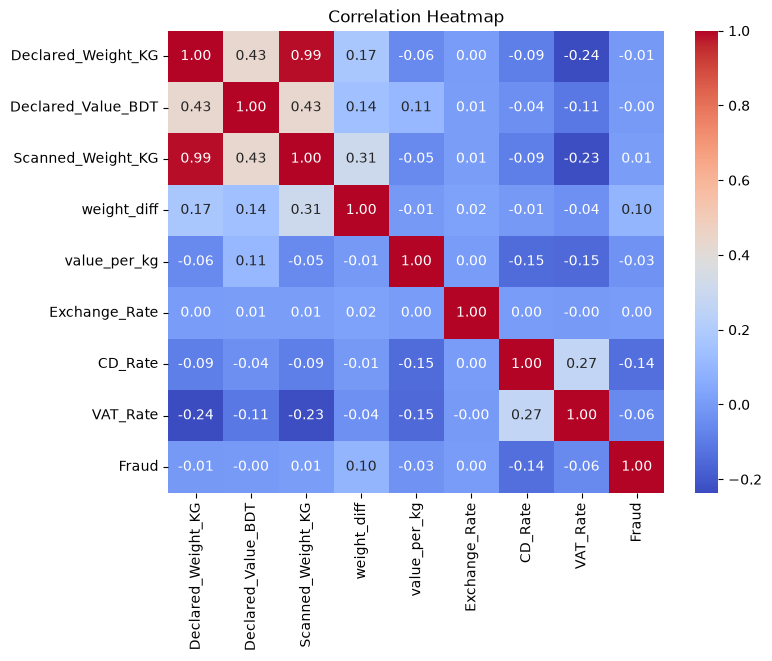

In [10]:
# correlation among numeric columns using heatmap
numeric_cols = ["Declared_Weight_KG", "Declared_Value_BDT", "Scanned_Weight_KG",
                 "weight_diff", "value_per_kg", "Exchange_Rate", "CD_Rate",
                 "VAT_Rate", "Fraud"]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()